# 3D Visualizations with Matplotlib – My Finance BA Version
Forked from JP Morgan Chase python-training repo  
Customized by S33mi(March 2026)

Goal: Learn 3D plotting techniques and apply them to **financial risk & portfolio analysis** – especially useful for visualizing:
- Risk-Return-Volume relationship
- Portfolio diversification in 3D space
- Volatility surface (implied volatility)

In [1]:
#Added by S33mi
%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import pandas as pd
import numpy as np
import yfinance as yf

# Better style for finance charts
plt.style.use('seaborn-v0_8')
sns.set_context("notebook", font_scale=1.1)

In [15]:
import pandas as pd
import numpy as np

import plotly.graph_objs as go

#import plotly.io as pio

# Force Colab renderer (this fixes most "no graph shown" issues)
#pio.renderers.default = 'colab'

#df = pd.read_csv('../data/yield_curve.csv') #if you are using local file system
url = "https://raw.githubusercontent.com/S33mi/jpmc-python-training-notes/main/data/yield_curve.csv" #if you dont want to upload file on colab
df = pd.read_csv(url)
xlist = list(df["x"].dropna())
ylist = list(df["y"].dropna())

del df["x"]
del df["y"]

zlist = []
for row in df.iterrows():
    index, data = row
    zlist.append(data.tolist())


In [18]:
z_secondary_beginning = [z[1] for z in zlist if z[0] == "None"]
z_secondary_end = [z[0] for z in zlist if z[0] != "None"]
z_secondary = z_secondary_beginning + z_secondary_end
x_secondary = ["3-month"] * len(z_secondary_beginning) + ["1-month"] * len(
    z_secondary_end
)
y_secondary = ylist

trace1 = dict(
    type="surface",
    x=xlist,
    y=ylist,
    z=zlist,
    hoverinfo="x+y+z",
    lighting={
        "ambient": 0.95,
        "diffuse": 0.99,
        "fresnel": 0.01,
        "roughness": 0.01,
        "specular": 0.01,
    },
    colorscale=[
        [0, "rgb(230,245,254)"],
        [0.4, "rgb(123,171,203)"],
        [0.8, "rgb(40,119,174)"],
        [1, "rgb(37,61,81)"],
    ],
    opacity=0.7,
    showscale=False,
    scene="scene",
)

trace2 = dict(
    type="scatter3d",
    mode="lines",
    x=x_secondary,
    y=y_secondary,
    z=z_secondary,
    hoverinfo="x+y+z",
    line=dict(color="#444444"),
)

data = [trace1, trace2]
layout = dict(
    autosize=True,
    font=dict(size=12, color="#CCCCCC"),
    margin=dict(t=5, l=5, b=5, r=5),
    showlegend=False,
    hovermode="closest",
    scene=dict(
        aspectmode="manual",
        aspectratio=dict(x=2, y=5, z=1.5),
        xaxis={
            "showgrid": True,
            "title": "",
            "type": "category",
            "zeroline": False,
            "categoryorder": "array",
            "categoryarray": list(reversed(xlist)),
        },
        yaxis={"showgrid": True, "title": "", "type": "date", "zeroline": False},
    ),
)
figure = dict(data=data, layout=layout)

#go.FigureWidget(figure) #doesnot work in colabs
fig = go.Figure(figure)   # Convert the dict to a proper Figure object
fig.show() #Show figure/output/graph
#Try to zoom in/out and rotate to adjust the view
#End of Orignal Notebook


# My Finance Extensions – 3D Plotting for Business Analysts
# (All original examples remain unchanged above)

Using real stock data from global stock exchange and markets.

In [20]:
# Fetch real data for 3D visualization
tickers = ['JPM', 'FROTO.IS', 'AMZN', 'BAC', 'AAPL', 'MSFT', 'TSLA']

data = yf.download(tickers, start="2024-01-01", progress=False)

prices = data['Close']
returns = prices.pct_change().dropna()
volume = data['Volume']

# Calculate key metrics for 3D plotting
metrics = pd.DataFrame({
    'Annual Return': returns.mean() * 252,
    'Annual Volatility': returns.std() * np.sqrt(252),
    'Avg Daily Volume': volume.mean()
}, index=tickers)

display(metrics.round(4))

/tmp/ipykernel_901/691265015.py:4: FutureWarning:

YF.download() has changed argument auto_adjust default to True

/tmp/ipykernel_901/691265015.py:7: FutureWarning:

The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.



,Annual Return,Annual Volatility,Avg Daily Volume
JPM,0.2810,0.2384,9.391476e+06
FROTO.IS,0.2652,0.3314,1.274345e+07
AMZN,0.1985,0.3078,4.349998e+07
BAC,0.2117,0.2448,3.920137e+07
AAPL,0.1757,0.2711,5.485177e+07
MSFT,0.0378,0.2317,2.285762e+07
TSLA,0.3791,0.6017,9.264004e+07


# High-Value Finance 3D Plots
###Risk-Return-Volume Scatter

/tmp/ipykernel_901/633091115.py:16: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



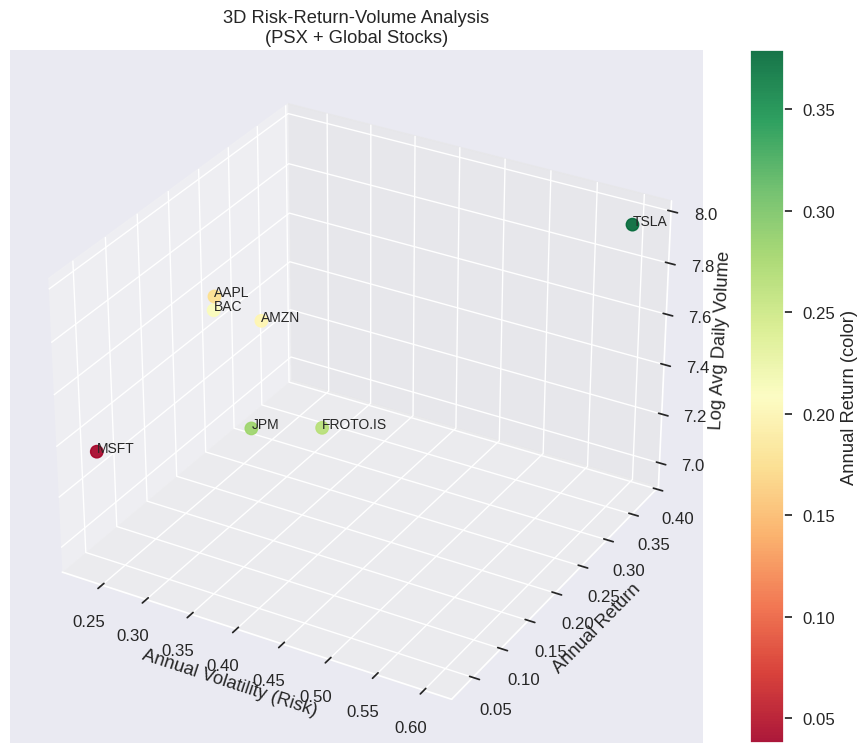

In [21]:
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

x = metrics['Annual Volatility']
y = metrics['Annual Return']
z = np.log10(metrics['Avg Daily Volume'])   # log volume for better scaling

scatter = ax.scatter(x, y, z,
                     s=80,
                     c=metrics['Annual Return'],
                     cmap='RdYlGn',
                     alpha=0.9)

# Annotate each point
for i, ticker in enumerate(metrics.index):
    ax.text(x[i], y[i], z[i], ticker, fontsize=10)

ax.set_xlabel('Annual Volatility (Risk)')
ax.set_ylabel('Annual Return')
ax.set_zlabel('Log Avg Daily Volume')
ax.set_title('3D Risk-Return-Volume Analysis\n(PSX + Global Stocks)')

plt.colorbar(scatter, label='Annual Return (color)')
plt.show()

###Surface Plot – Rolling Correlation Example

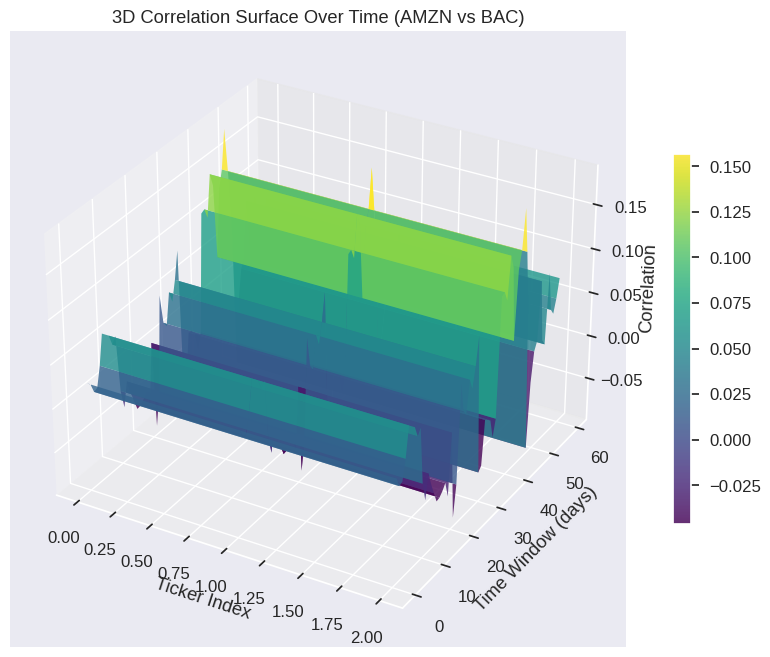

In [33]:
# Create a small 3D surface (example: correlation evolution)
np.random.seed(42)

tickers_sample = ['AMZN', 'BAC', 'AAPL']
days = 60
window_size = 30

# Select only these 3 columns
returns_sample = returns[tickers_sample]          # <-- This is the key line

corr_matrix = np.zeros((days, 3, 3))

for i in range(days):
    window = returns_sample.iloc[i:i+window_size]
    if len(window) < window_size:          # avoid last incomplete windows
        break
    corr_matrix[i] = window.corr().values

# ==================== Plotting ====================
X, Y = np.meshgrid(range(3), range(len(corr_matrix)))   # use actual length

# Simple surface: correlation between AMZN and BAC over time
#X, Y = np.meshgrid(range(3), range(days))
#Z = corr_matrix[:, 0, 1].reshape(days, 1)   # example slice

# Example: correlation between AMZN (0) and BAC (1) over time
Z = corr_matrix[:, 0, 1].reshape(-1, 1)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)

ax.set_xlabel('Ticker Index')
ax.set_ylabel('Time Window (days)')
ax.set_zlabel('Correlation')
ax.set_title('3D Correlation Surface Over Time (AMZN vs BAC)')

plt.colorbar(surf, shrink=0.6)
plt.show()

###Interactive 3D Scatter with Widgets

In [27]:
from ipywidgets import interact, IntSlider

@interact(window=IntSlider(min=30, max=120, step=10, value=60))
def plot_3d_risk_return(window):
    roll_ret = returns.rolling(window).mean() * 252
    roll_vol = returns.rolling(window).std() * np.sqrt(252)

    fig = plt.figure(figsize=(11, 8))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(roll_vol.iloc[-1], roll_ret.iloc[-1],
               np.log10(volume.mean()),
               s=100, c=roll_ret.iloc[-1], cmap='RdYlGn')

    ax.set_xlabel('Rolling Volatility')
    ax.set_ylabel('Rolling Return')
    ax.set_zlabel('Log Volume')
    ax.set_title(f'3D View – {window}-day Rolling Risk-Return-Volume')
    plt.show()

interactive(children=(IntSlider(value=60, description='window', max=120, min=30, step=10), Output()), _dom_cla…

You can see from the above given examples that seaborn and matplotlib can't provide you intrective or good plots/graphs. They are good only for basic plots. For more beautiful and interactive graphs we should use Plotly  

## Bonus: Fully Interactive 3D Scatter Plot using Plotly
Plotly version of the Risk-Return-Volume visualization.  
Features:
- Fully rotatable & zoomable
- Hover tooltips with exact values
- Beautiful colors and professional look
- Works great in reports and presentations

In [34]:
# Bonus: Interactive 3D Risk-Return-Volume Plot with Plotly

import plotly.express as px
import plotly.graph_objects as go
import numpy as np

# Use the same metrics DataFrame we created earlier
# (If you haven't run the earlier data fetching cell, run it first)

metrics = pd.DataFrame({
    'Annual Return': returns.mean() * 252,
    'Annual Volatility': returns.std() * np.sqrt(252),
    'Avg Daily Volume': volume.mean(),
    'Market Cap': [yf.Ticker(t).info.get('marketCap', 0) for t in tickers]
}, index=tickers)

# Create interactive 3D scatter
fig = px.scatter_3d(
    metrics.reset_index(),
    x='Annual Volatility',
    y='Annual Return',
    z=np.log10(metrics['Avg Daily Volume']),   # Log scale for better visualization
    color='Annual Return',                     # Color by return
    size='Market Cap',                         # Size by market cap
    hover_name='index',                        # Ticker as hover name
    hover_data={
        'Annual Return': ':.4f',
        'Annual Volatility': ':.4f',
        'Avg Daily Volume': ':.0f',
        'Market Cap': ':.0f'
    },
    color_continuous_scale='RdYlGn',           # Red → Yellow → Green
    title='Interactive 3D Risk-Return-Volume Analysis<br><sup>Global Stocks (Hover for details)</sup>',
    labels={
        'Annual Volatility': 'Annual Volatility (Risk)',
        'Annual Return': 'Annual Return',
        'z': 'Log10(Avg Daily Volume)'
    },
    width=900,
    height=700
)

# Improve layout
fig.update_layout(
    scene=dict(
        xaxis_title='Annual Volatility (Risk)',
        yaxis_title='Annual Return',
        zaxis_title='Log10(Avg Daily Volume)',
        camera=dict(
            eye=dict(x=1.8, y=1.8, z=1.2)   # Nice initial viewing angle
        )
    ),
    margin=dict(l=0, r=0, b=0, t=50),
    coloraxis_colorbar=dict(title="Annual Return")
)

# Add annotation for zones
fig.add_annotation(
    text="Safe Zone (High Return, Low Risk)",
    xref="paper", yref="paper",
    x=0.02, y=0.95,
    showarrow=False,
    font=dict(size=12, color="green")
)

fig.show()

# Optional: Export as HTML (interactive file you can share)
fig.write_html("3d_risk_return_interactive.html")
print("Interactive plot saved as '3d_risk_return_interactive.html'")

Interactive plot saved as '3d_risk_return_interactive.html'


In [29]:
# Alternative: Using go.Scatter3d for more customization
fig = go.Figure(data=[go.Scatter3d(
    x=metrics['Annual Volatility'],
    y=metrics['Annual Return'],
    z=np.log10(metrics['Avg Daily Volume']),
    mode='markers+text',
    text=metrics.index,
    textposition='top center',
    marker=dict(
        size=metrics['Market Cap'] / 1e10,   # scale down market cap
        color=metrics['Annual Return'],
        colorscale='RdYlGn',
        opacity=0.85,
        colorbar=dict(title="Annual Return")
    )
)])

fig.update_layout(
    title="Custom 3D Risk-Return-Volume Plot (Plotly)",
    scene=dict(
        xaxis_title='Volatility',
        yaxis_title='Return',
        zaxis_title='Log Volume'
    ),
    width=950,
    height=750
)

fig.show()

## Key Takeaways from My Extensions

- Applied 3D plotting to real financial metrics (Risk × Return × Volume)
- Created a **Risk-Return-Volume cube** – very useful for portfolio review meetings
- Used color mapping and annotations for better storytelling
- Added interactivity using ipywidgets and plotly

### Recommended BA Exercises
1. Add more stocks and observe clustering in 3D space.
2. Create a 3D surface of Implied Volatility (if you have options data).
3. Export high-quality images: `plt.savefig('3d_risk_return.png', dpi=300, bbox_inches='tight')`
4. Try `plotly` for fully interactive 3D charts (bonus challenge).

This notebook now bridges the original teaching material with modern finance visualization skills.